<center>
  <h2>Prelims 2024</h2>
  <h3>Mani Tyagi</h3>
  <h4>200973108</h4>
</center>

In [135]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

### Part (1)

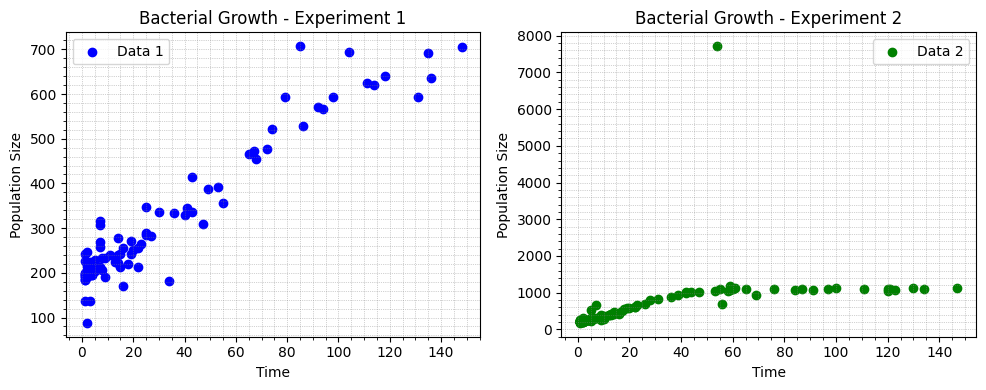

In [136]:
# Load the data 
data1 = np.loadtxt('bacteria1.txt')
data2 = np.loadtxt('bacteria2.txt')

# Extract time and population size
time1, population1 = data1[:, 0], data1[:, 1]
time2, population2 = data2[:, 0], data2[:, 1]

# Plot the raw data
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(time1, population1, label='Data 1', color='blue')
plt.xlabel('Time')
plt.ylabel('Population Size')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.title('Bacterial Growth - Experiment 1')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(time2, population2, label='Data 2', color='green')
plt.xlabel('Time')
plt.ylabel('Population Size')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.title('Bacterial Growth - Experiment 2')
plt.legend()

plt.tight_layout()
plt.show()

In [137]:
# Define the logistic growth model
def logistic_growth(t, K, r, P0=100):
    return K / (1 + ((K - P0) / P0) * np.exp(-r * t))

### Part (2)

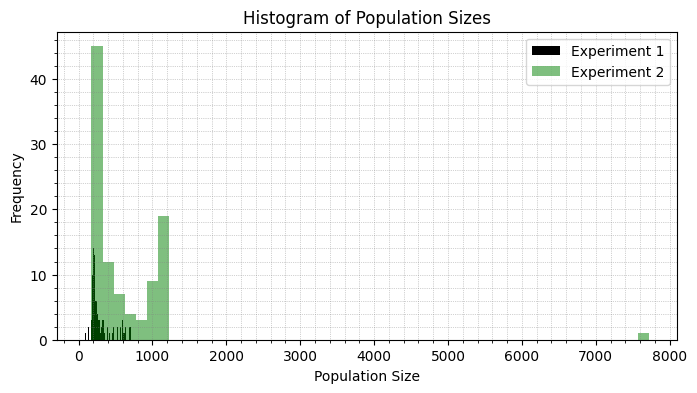

In [138]:
# Plot histograms of the data
plt.figure(figsize=(8, 4))
plt.hist(population1, bins=50, alpha=1, label='Experiment 1', color='black')
plt.hist(population2, bins=50, alpha=0.5, label='Experiment 2', color='green')
plt.xlabel('Population Size')
plt.ylabel('Frequency')
plt.title('Histogram of Population Sizes')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.legend()
plt.show()

### Part (3)

In [139]:
# Define the logistic growth model
def logistic_growth(t, K, r, P0=100):
    return K / (1 + ((K - P0) / P0) * np.exp(-r * t))

# Define the log likelihood function
def log_likelihood(K, r, t, population):
    predicted = logistic_growth(t, K, r)
    return -0.5 * np.sum((population - predicted) ** 2)

# Define proposal distribution for Metropolis-Hastings
def proposal(param, scale=[0.1, 0.01]):
    return [param[i] + scale[i] * np.random.randn() for i in range(len(param))]

# Metropolis-Hastings algorithm
def metropolis_hastings(t, population, iterations=100000, burn_in=1000):
    K_current, r_current = 100, 0.1
    log_likelihood_current = log_likelihood(K_current, r_current, t, population)
    
    samples = []
    accepted = 0
    
    for _ in range(iterations):
        K_proposal, r_proposal = proposal([K_current, r_current])
        if K_proposal <= 0 or r_proposal <= 0:
            continue
        
        log_likelihood_proposal = log_likelihood(K_proposal, r_proposal, t, population)
        log_acceptance_ratio = log_likelihood_proposal - log_likelihood_current
        if log_acceptance_ratio > 0 or np.log(np.random.rand()) < log_acceptance_ratio:
            K_current, r_current = K_proposal, r_proposal
            log_likelihood_current = log_likelihood_proposal
            accepted += 1
            
        samples.append([K_current, r_current])
    
    samples = np.array(samples[burn_in:])
    return samples

# Run MCMC for both experiments
samples1 = metropolis_hastings(time1, population1)
samples2 = metropolis_hastings(time2, population2)

# Print parameters for both samples
print("Parameters for Experiment 1:")
print("Mean K:", np.mean(samples1[:, 0]))
print("Mean r:", np.mean(samples1[:, 1]))
print("Final K:", samples1[-1, 0])
print("Final r:", samples1[-1, 1])

print("\nParameters for Experiment 2:")
print("Mean K:", np.mean(samples2[:, 0]))
print("Mean r:", np.mean(samples2[:, 1]))
print("Final K:", samples2[-1, 0])
print("Final r:", samples2[-1, 1])

Parameters for Experiment 1:
Mean K: 541.3433374658505
Mean r: 0.11593567195279147
Final K: 623.2834238526153
Final r: 0.049664715269735274

Parameters for Experiment 2:
Mean K: 956.9329895434759
Mean r: 0.23885131308370275
Final K: 1242.9371040472854
Final r: 0.12166708855120585


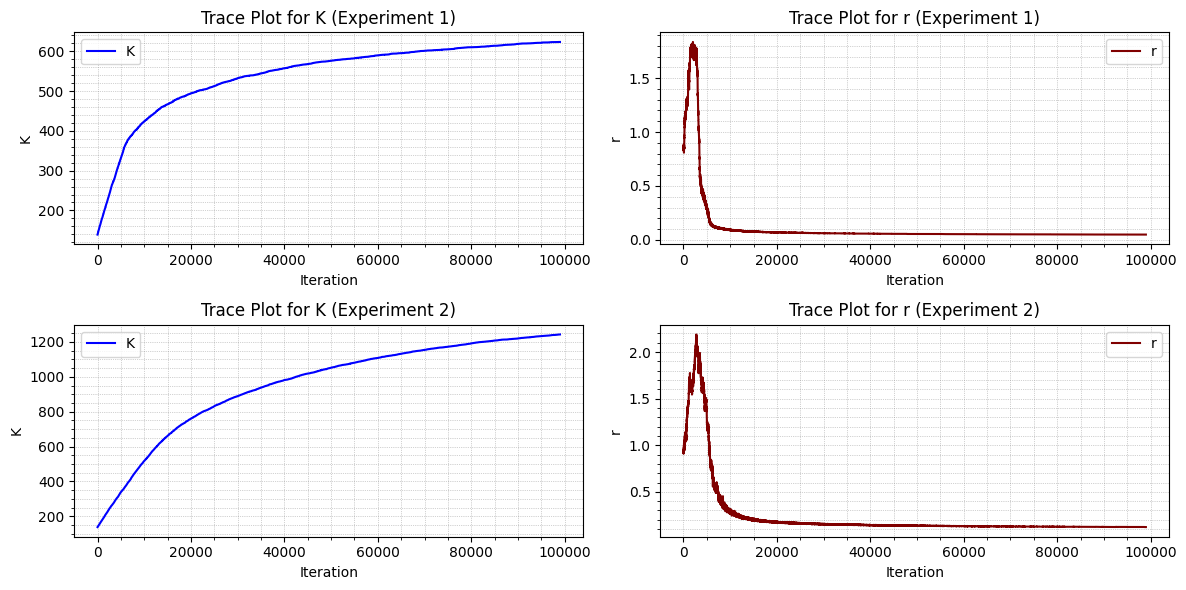

In [140]:
# Plot the trace plots
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.plot(samples1[:, 0], label='K', color='blue')
plt.xlabel('Iteration')
plt.ylabel('K')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.title('Trace Plot for K (Experiment 1)')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(samples1[:, 1], label='r', color='maroon')
plt.xlabel('Iteration')
plt.ylabel('r')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.title('Trace Plot for r (Experiment 1)')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(samples2[:, 0], label='K', color='blue')
plt.xlabel('Iteration')
plt.ylabel('K')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.title('Trace Plot for K (Experiment 2)')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(samples2[:, 1], label='r', color='maroon')
plt.xlabel('Iteration')
plt.ylabel('r')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.title('Trace Plot for r (Experiment 2)')
plt.legend()

plt.tight_layout()
plt.show()

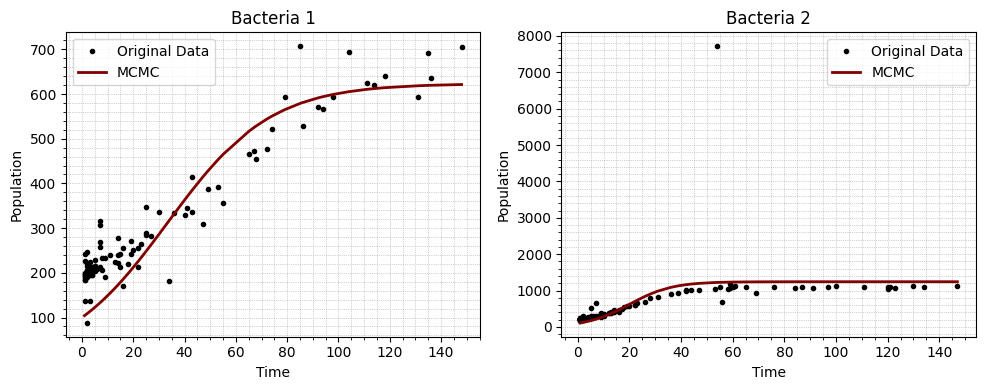

In [148]:
def plot_logistic_growth(ax, t, population, K, r, i):
    if i == 1:
        color_plot = 'maroon'
        label_plot = 'MCMC'
        ax.plot(t, population, color='black', marker='.', linestyle='', label='Original Data')    
        
    else:
        color_plot = 'green'
        label_plot = 'EM'
        
    ax.plot(t, logistic_growth(t, K, r), color=color_plot, lw=2, linestyle='-', label=label_plot)
    ax.set_xlabel('Time')
    ax.set_ylabel('Population')
    ax.minorticks_on()
    ax.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
    ax.legend()

# Plot comparison for Experiment 1 with custom colors
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plot_logistic_growth(plt.gca(), time1, population1, samples1[-1, 0], samples1[-1, 1], 1)
plt.title('Bacteria 1')

# Plot comparison for Experiment 2 with custom colors
plt.subplot(1, 2, 2)
plot_logistic_growth(plt.gca(), time2, population2, samples2[-1, 0], samples2[-1, 1], 1)

plt.title('Bacteria 2')

plt.tight_layout()
plt.show()


### Part (4)

In [166]:
# Expectation step: compute expected values of the latent variable
def expectation_step(t, population, K, r):
    predicted = logistic_growth(t, K, r)
    return predicted

# Maximization step: update parameters based on expected values
def maximization_step(t, population, expected_population, K, r):
    epsilon = 1e-6  # Small value to avoid division by zero
    
    numerator_K = np.sum(expected_population)
    denominator_K = np.sum(1 - np.exp(-r * t))
    K_new = numerator_K / (denominator_K + epsilon)

    numerator_r = np.sum((population - expected_population) * K * t * np.exp(-r * t))
    denominator_r = np.sum((expected_population) * K * t ** 2 * np.exp(-r * t))
    
    if np.abs(denominator_r) < epsilon:
        r_new = 0 
    else:
        r_new = numerator_r / (denominator_r + epsilon)

    return K_new, r_new

# EM algorithm with tracking of parameter values
def expectation_maximization_with_tracking(t, population, iterations=10000, tol=1e-12):
    # Initialize parameters
    K, r = 1, 0.01
    K_values, r_values = [K], [r]
    
    for _ in range(iterations):
        # Expectation step
        expected_population = expectation_step(t, population, K, r)
        
        # Maximization step
        K_new, r_new = maximization_step(t, population, expected_population, K, r)
        
        # Append K and r values to the lists
        K_values.append(K_new)
        r_values.append(r_new)
        
        # Check for convergence
        if np.abs(K_new - K) < tol and np.abs(r_new - r) < tol:
            break
        
        K, r = K_new, r_new
    
    return K_values, r_values


# Perform EM algorithm with tracking for both experiments
K_values1, r_values1 = expectation_maximization_with_tracking(time1, population1)
K_values2, r_values2 = expectation_maximization_with_tracking(time2, population2)

# Print the final K and r values
print("Final K and r values for Experiment 1:")
print("K:", K_values1[-1])
print("r:", r_values1[-1])

print("\nFinal K and r values for Experiment 2:")
print("K:", K_values2[-1])
print("r:", r_values2[-1])


Final K and r values for Experiment 1:
K: 527.5037822581085
r: 0.016207137920076883

Final K and r values for Experiment 2:
K: 401.8597437673863
r: 0.07674958435022464


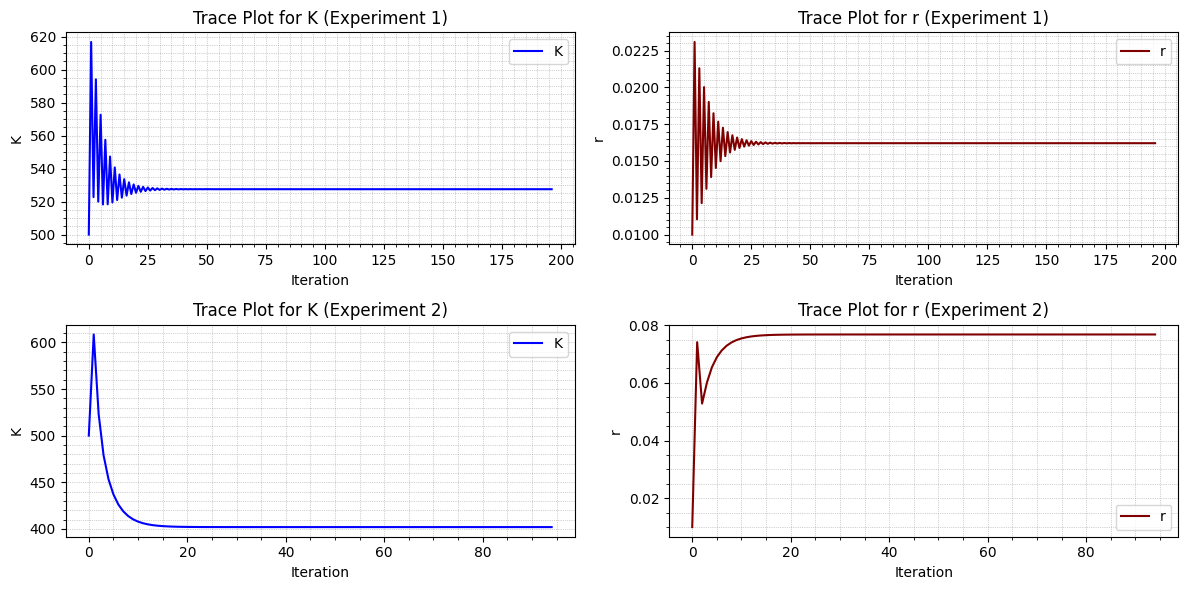

In [150]:
# Plot the trace plots
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.plot(range(len(K_values1)), K_values1, label='K', color='blue')
plt.xlabel('Iteration')
plt.ylabel('K')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.title('Trace Plot for K (Experiment 1)')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(range(len(r_values1)), r_values1, label='r', color='maroon')
plt.xlabel('Iteration')
plt.ylabel('r')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.title('Trace Plot for r (Experiment 1)')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(range(len(K_values2)), K_values2, label='K', color='blue')
plt.xlabel('Iteration')
plt.ylabel('K')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.title('Trace Plot for K (Experiment 2)')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(range(len(r_values2)), r_values2, label='r', color='maroon')
plt.xlabel('Iteration')
plt.ylabel('r')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.title('Trace Plot for r (Experiment 2)')
plt.legend()

plt.tight_layout()
plt.show()

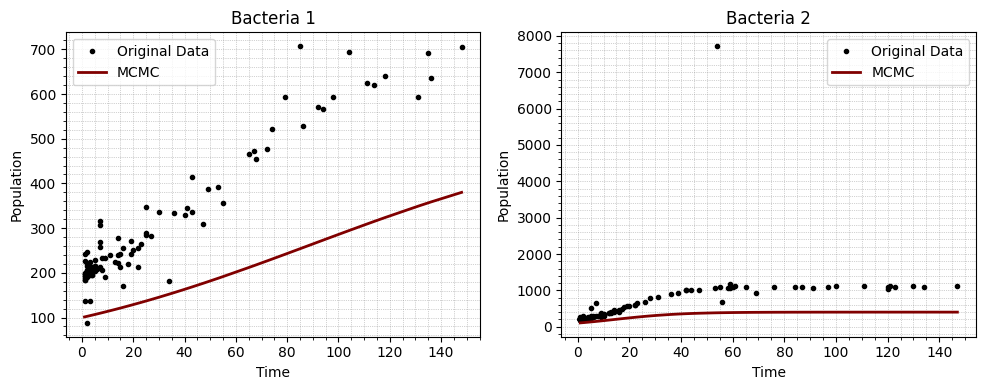

In [151]:
# Plot comparison
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plot_logistic_growth(plt.gca(), time1, population1, K_values1[-1], r_values1[-1], 1)
plt.title('Bacteria 1')

# Plot comparison for Experiment 2 with custom colors
plt.subplot(1, 2, 2)
plot_logistic_growth(plt.gca(), time2, population2, K_values2[-1], r_values2[-1], 1)

plt.title('Bacteria 2')

plt.tight_layout()
plt.show()


### Part (5)

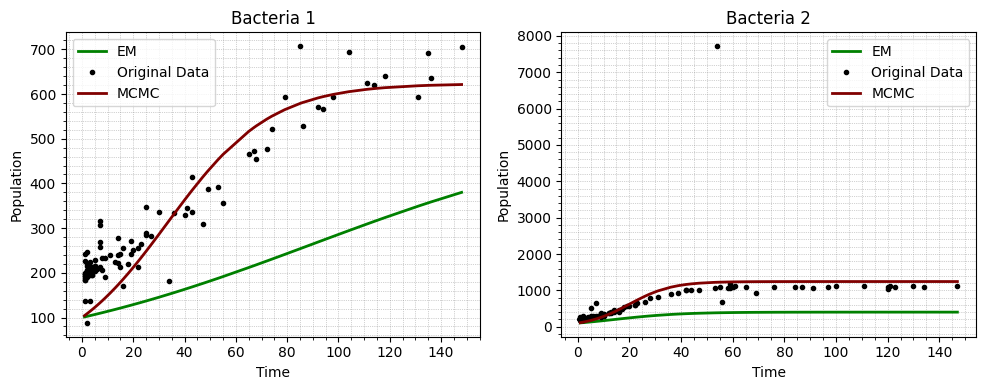

In [152]:
# Plot comparison
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plot_logistic_growth(plt.gca(), time1, population1, K_values1[-1], r_values1[-1], 0)
plot_logistic_growth(plt.gca(), time1, population1, samples1[-1, 0], samples1[-1, 1], 1)
plt.title('Bacteria 1')

# Plot comparison for Experiment 2 with custom colors
plt.subplot(1, 2, 2)
plot_logistic_growth(plt.gca(), time2, population2, K_values2[-1], r_values2[-1], 0)
plot_logistic_growth(plt.gca(), time2, population2, samples2[-1, 0], samples2[-1, 1], 1)
plt.title('Bacteria 2')

plt.tight_layout()
plt.show()


In [161]:
# Final parameter values for Bacteria 1 and 2 from MCMC samples
final_K1_mcmc = samples1[-1, 0]
final_r1_mcmc = samples1[-1, 1]
final_K2_mcmc = samples2[-1, 0]
final_r2_mcmc = samples2[-1, 1]

# Final parameter values for Bacteria 1 and 2 from EM algorithm
final_K1_em = K_values1[-1]
final_r1_em = r_values1[-1]
final_K2_em = K_values2[-1]
final_r2_em = r_values2[-1]

# Print header
print("="*92)
print(f"{'Parameter':<12} {'Bacteria 1 (MCMC)':<20} {'Bacteria 1 (EM)':<20} {'Bacteria 2 (MCMC)':<20} {'Bacteria 2 (EM)':<20}")
print("="*92)

# Print results for K
print(f"{'K':<12} {final_K1_mcmc:<20.2f} {final_K1_em:<20.2f} {final_K2_mcmc:<20.2f} {final_K2_em:<20.2f}")

# Print results for r
print(f"{'r':<12} {final_r1_mcmc:<20.4f} {final_r1_em:<20.4f} {final_r2_mcmc:<20.4f} {final_r2_em:<20.4f}")
print("="*92)


Parameter    Bacteria 1 (MCMC)    Bacteria 1 (EM)      Bacteria 2 (MCMC)    Bacteria 2 (EM)     
K            623.28               527.50               1242.94              401.86              
r            0.0497               0.0162               0.1217               0.0767              
